In [1]:
import os
import SimpleITK as sitk
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

## Global Variables

In [2]:
linux_prefix = '/media/kratos'
mac_prefix = '/Volumes'

## USER DEFINED VARIABLES
prefix = linux_prefix
model = 207
motion = 'KEY'
bone = 'MC1'
frame = 3
dilation_kernel = (15, 15, 15)

if motion == 'ABAD':
    cursor_position = [146, 294, 90]
elif motion == 'KEY':
    cursor_position = [229, 151, 117]
elif motion == 'OPP':
    cursor_position = [333, 207, 124]

dynact_dir_suffix = f'Manskelab/ManskelabProjects/DYNACT2/models/DYNACT2_{model}/DYNACT2_{model}_{motion}/RESAMPLED'
output_dir_suffix = f'Manskelab/ManskelabProjects/DYNACT2/models/DYNACT2_{model}/DYNACT2_{model}_{motion}/REGISTRATION'
wbct_segmentation_suffix = f'Manskelab/ManskelabProjects/DYNACT2/models/DYNACT2_{model}/DYNACT2_{model}_WBCT/DYNACT2_{model}_WBCT_CROP_PERI_{bone}_BB_REORIENT_{motion}_TRANSF.nii'

dynact_dir = os.path.join(prefix, dynact_dir_suffix)
output_dir = os.path.join(prefix, output_dir_suffix)
mc1_wbct_segmentation = os.path.join(prefix, wbct_segmentation_suffix)

## Definitions

In [3]:
def print_image(image, full=True, title=""):
    """
    Plots 3 views of sitk image similar to what a user would see in ITK-SNAP. 

    Parameters
    ----------
    image : SimpleITK.Image
    full : boolean, if true, plots slices based on set cursor location otherwise plots middle slices
    title: string

    Returns
    -------
    none
    """
    if full:
        z = cursor_position[2]
        x = cursor_position[0]
        y = cursor_position[1]
    else:
        z = image.GetDepth() // 2
        x = image.GetWidth() // 2
        y = image.GetHeight() // 2
    
    array = sitk.GetArrayViewFromImage(image)
    array_transposed = np.transpose(array, axes=(2, 1, 0))
    title = f"{title}\nShape: {array_transposed.shape})"
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5)) 
    
    # Rotate and mirror arrays
    rotated_z = np.rot90(array_transposed[:, :, z], k=-1)
    mirrored_z = np.fliplr(rotated_z)
    
    rotated_y = np.rot90(array_transposed[:, y, :], k=-1)
    mirrored_y = np.fliplr(rotated_y)
    mirrored_y = np.flipud(mirrored_y)
    
    rotated_x = np.rot90(array_transposed[x, :, :], k=-1)
    mirrored_x = np.flipud(rotated_x)
    mirrored_x = np.fliplr(mirrored_x)

    axes[0].imshow(mirrored_z, cmap=plt.cm.Greys_r)
    axes[0].axis("off")
    axes[0].set_title("Transverse Plane")

    axes[1].imshow(mirrored_y, cmap=plt.cm.Greys_r)
    axes[1].axis("off")
    axes[1].set_title("Coronal Plane")
    
    axes[2].imshow(mirrored_x, cmap=plt.cm.Greys_r)
    axes[2].axis("off")
    axes[2].set_title("Sagittal Plane")

    if title:
        fig.suptitle(title, fontsize=16)
    plt.tight_layout() 
    plt.show()

In [4]:
def bounding_box(mask, min_val, max_val):
    """
    Computes the bounding box of the input mask and crops the mask using the
    size and starting location of the bounding box.

    Parameters
    ----------
    mask : SimpleITK.Image

    Returns
    -------
    bounding_box_image : SimpleITK.Image
    """
    # Run connected components
    connected_comp = sitk.ConnectedComponentImageFilter()
    connected_comp_img = connected_comp.Execute(mask)

    # Relabel and sort by object size
    relabel = sitk.RelabelComponentImageFilter()
    relabel.SortByObjectSizeOn()
    relabel_img = relabel.Execute(connected_comp_img)

    thresh = sitk.BinaryThresholdImageFilter()
    thresh.SetLowerThreshold(min_val)
    thresh.SetUpperThreshold(max_val)
    thresh.SetOutsideValue(0)
    thresh.SetInsideValue(1)
    thresh_img = thresh.Execute(mask)

    stats_filter = sitk.LabelShapeStatisticsImageFilter()
    stats_filter.Execute(thresh_img)
  
    # Get the bounding box. Returns an array in the format:
    # [x_start, y_start, z_start, x_size, y_size, z_size]
    bounding_box_dim = np.array(stats_filter.GetBoundingBox(1))
    x_start = bounding_box_dim[0]
    y_start = bounding_box_dim[1]
    z_start = bounding_box_dim[2]
    x_end = x_start + bounding_box_dim[3]
    y_end = y_start + bounding_box_dim[4]
    z_end = z_start + bounding_box_dim[5]

    # Crop the image with the bounding box
    bounding_box_image = thresh_img[x_start:x_end, y_start:y_end, z_start:z_end]

    return bounding_box_image


## Registration Code

#### Loading Frame 1 Dynamic CT and MC1 Segmentation from WBCT

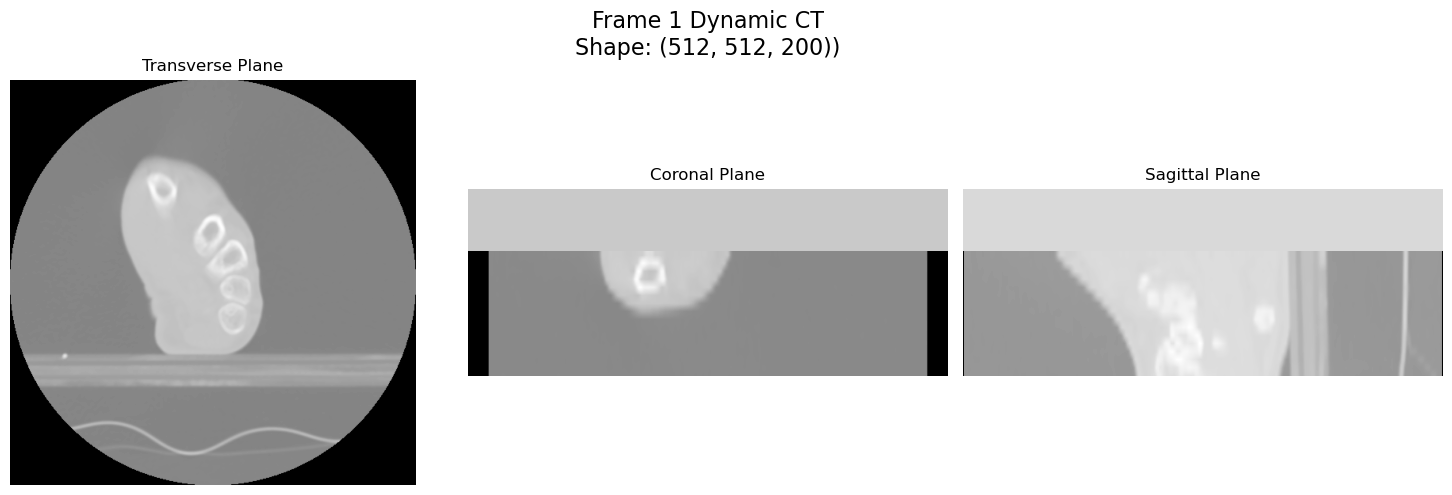

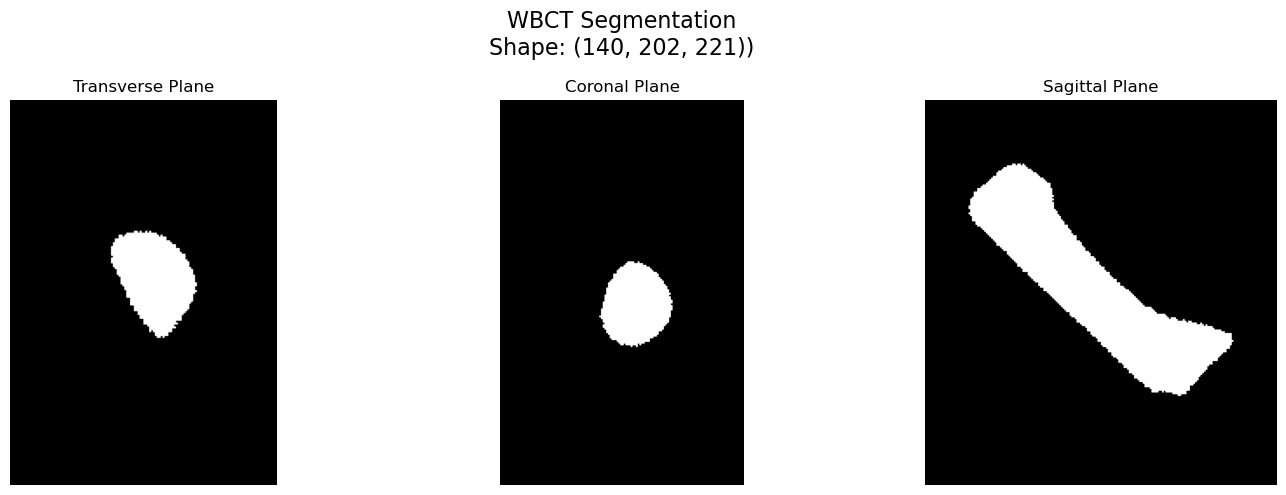

In [5]:
frame_1_dynact_path = os.path.join(dynact_dir, "Volume_" + str(1) + "_Resampled.nii")
frame_1_dynact = sitk.ReadImage(frame_1_dynact_path, sitk.sitkFloat32)
frame_1_mc1_seg = sitk.ReadImage(mc1_wbct_segmentation, sitk.sitkUInt8)

print_image(frame_1_dynact, title="Frame 1 Dynamic CT")
print_image(frame_1_mc1_seg, full=False, title="WBCT Segmentation")

#### Masking Frame 1 MC1 with WBCT Segmentation

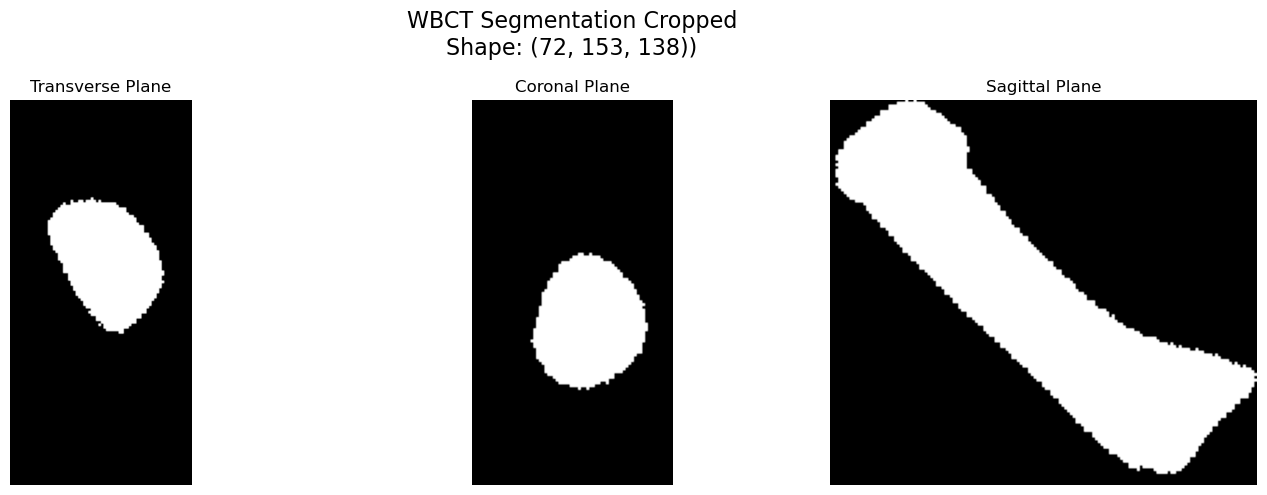

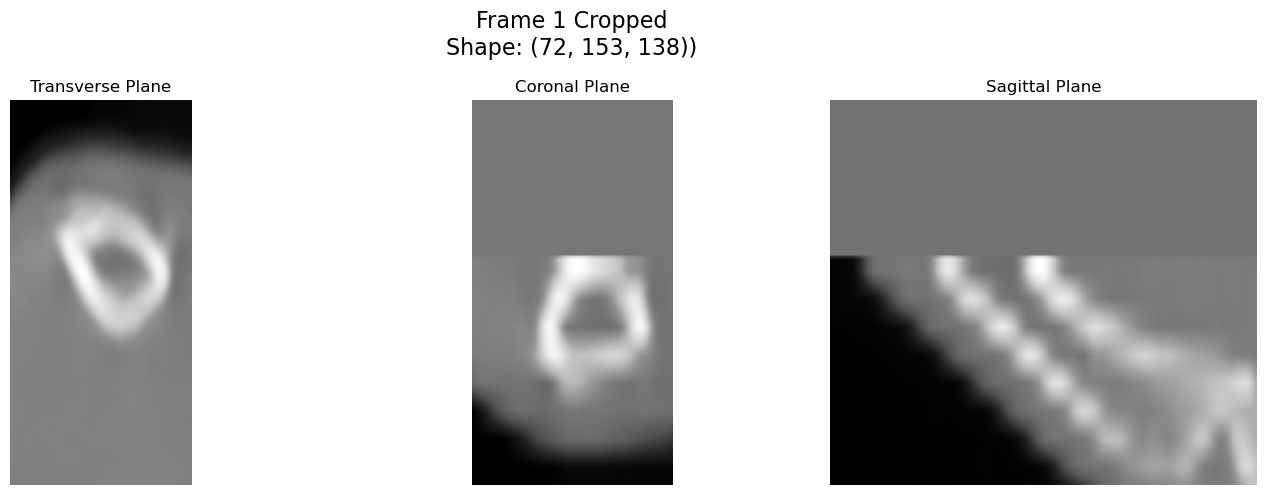

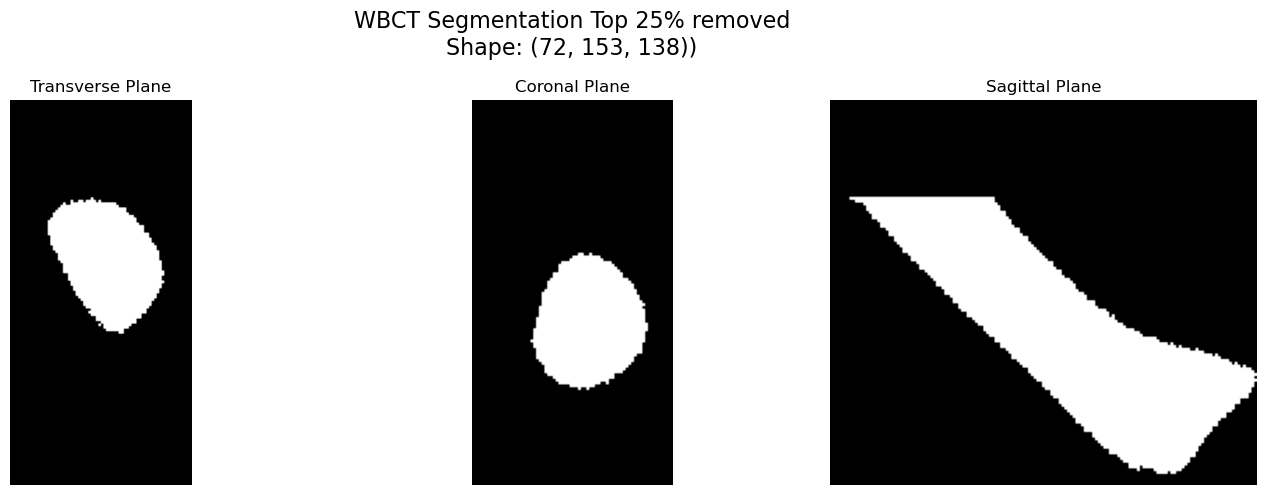

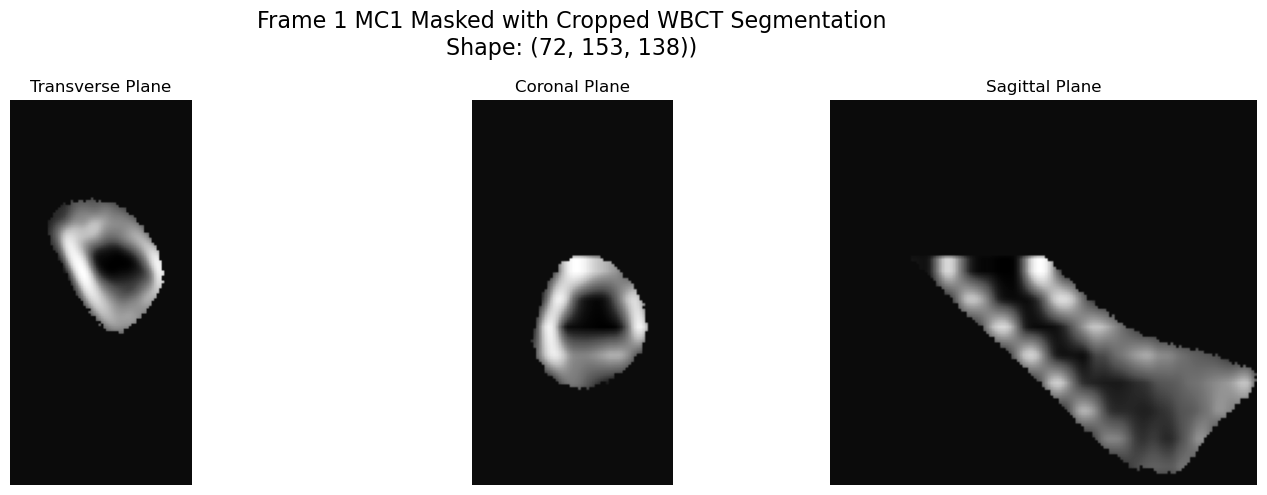

In [6]:
# cropping area of interest in WBCT segmentation
mask = bounding_box(frame_1_mc1_seg, 1, 1)
print_image(mask, full=False, title='WBCT Segmentation Cropped')

# resample dynamic ct frame to match cropped image dimensions
frame_1_dynact = sitk.Resample(frame_1_dynact, mask)
print_image(frame_1_dynact, full=False, title='Frame 1 Cropped')

# cut off top 25% of WBCT mask 
mask = sitk.Resample(mask[:,:,0:int(mask.GetSize()[2]*0.75)], mask)
print_image(mask, full=False, title='WBCT Segmentation Top 25% removed')

# apply mask on dynamic ct frame 1
frame_1_dynact = sitk.Mask(frame_1_dynact, mask)
print_image(frame_1_dynact, full=False, title="Frame 1 MC1 Masked with Cropped WBCT Segmentation")

#### Calculating Total Intensity of Mask and Tolerance

In [7]:
tolerance = 0.15
start_intensity_mc1 = ((sitk.GetArrayFromImage(frame_1_dynact)[(sitk.GetArrayFromImage(mask) > 0) & (np.absolute(sitk.GetArrayFromImage(frame_1_dynact)) > 0)])).mean()
tolerance = tolerance * start_intensity_mc1
print(f"Frame 1 Intensity = {start_intensity_mc1}")
print(f"Tolerance = +/-{tolerance}")

Frame 1 Intensity = 493.4575500488281
Tolerance = +/-74.01863250732421


#### Resampling WBCT MC1 Segmentation onto Full Hand Dynamic CT

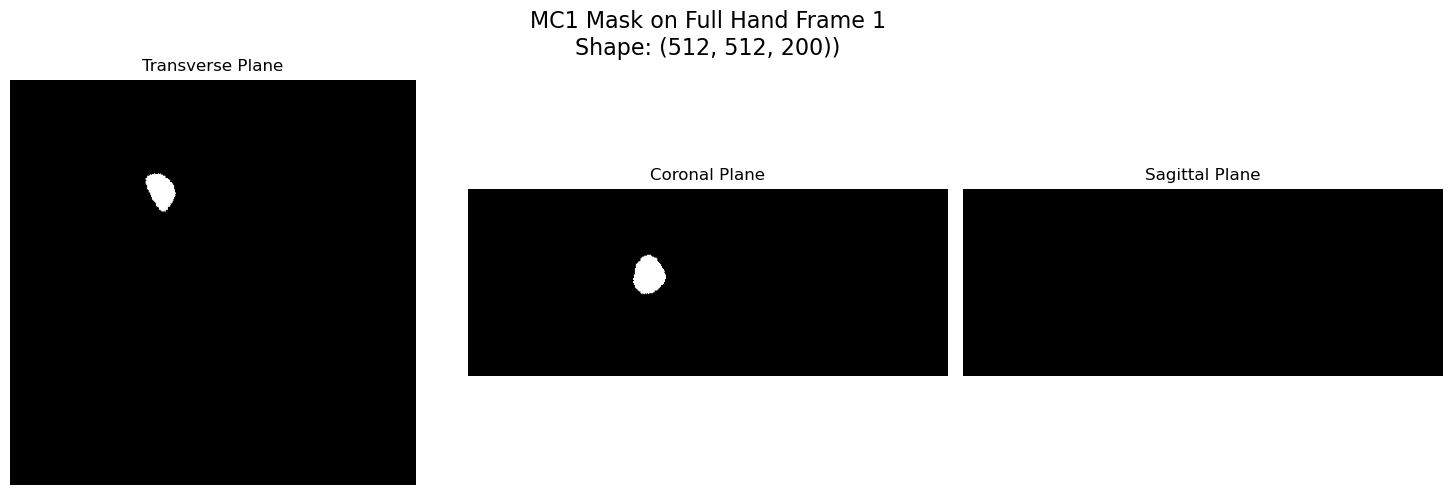

In [8]:
# sometimes these are different if user decides to start on a frame > 1
start_frame_dynact = sitk.ReadImage(frame_1_dynact_path, sitk.sitkFloat32)
mc1_seg_start = sitk.ReadImage(mc1_wbct_segmentation, sitk.sitkUInt8)

mc1_seg_resampled = sitk.Resample(mc1_seg_start, start_frame_dynact, interpolator=sitk.sitkNearestNeighbor)
print_image(mc1_seg_resampled, title="MC1 Mask on Full Hand Frame 1")

#### Loading in Prev and Current Images + Using Binary Threashold to Get Hand Segment

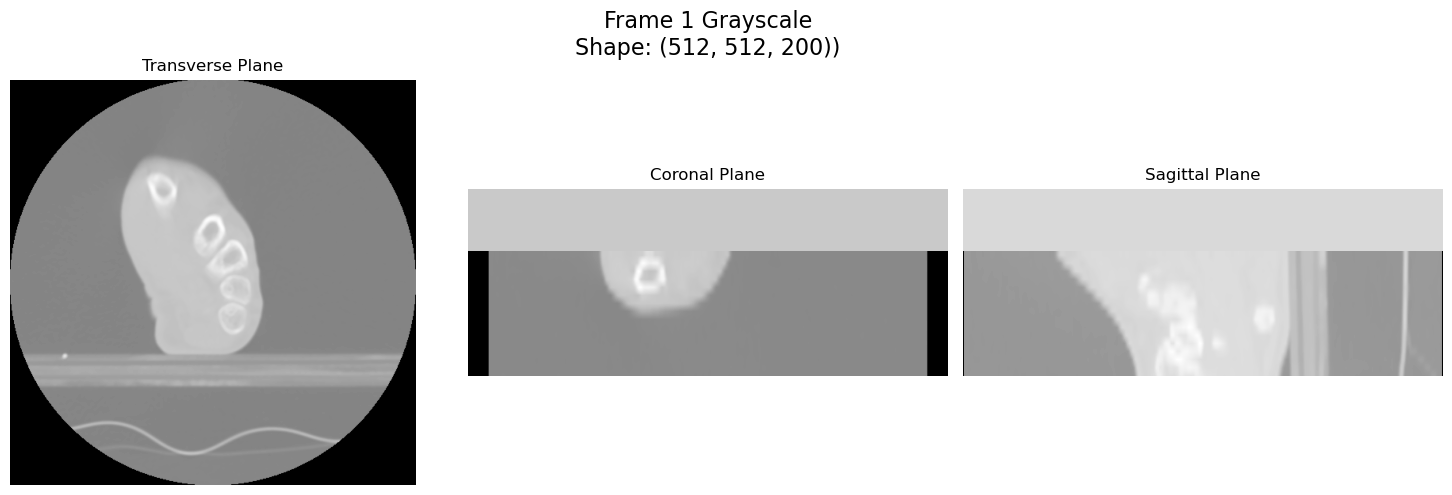

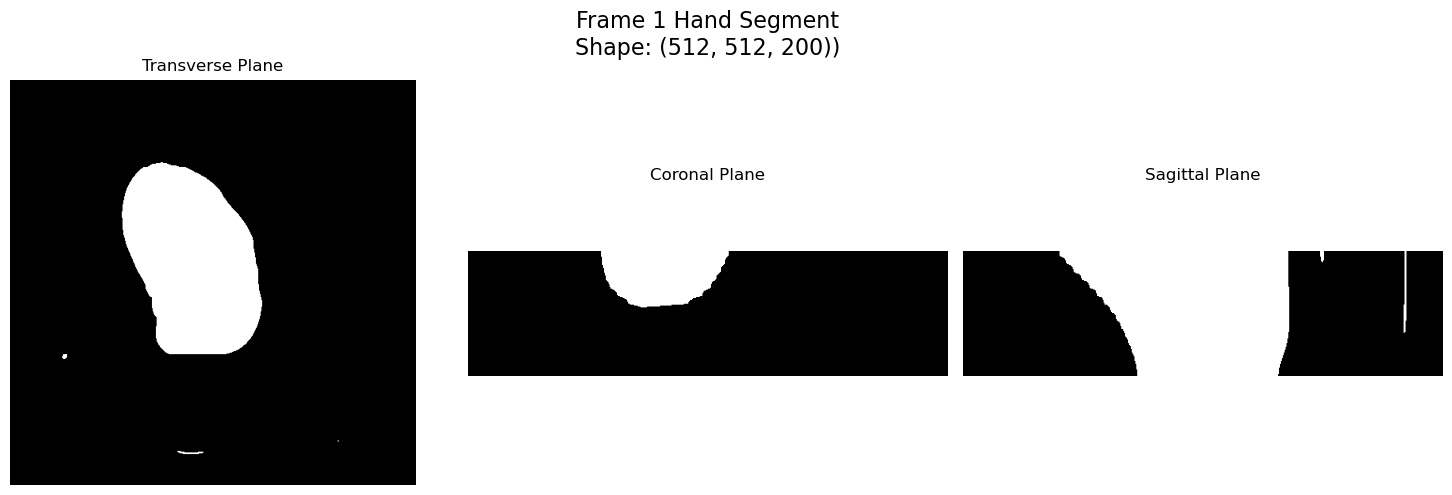

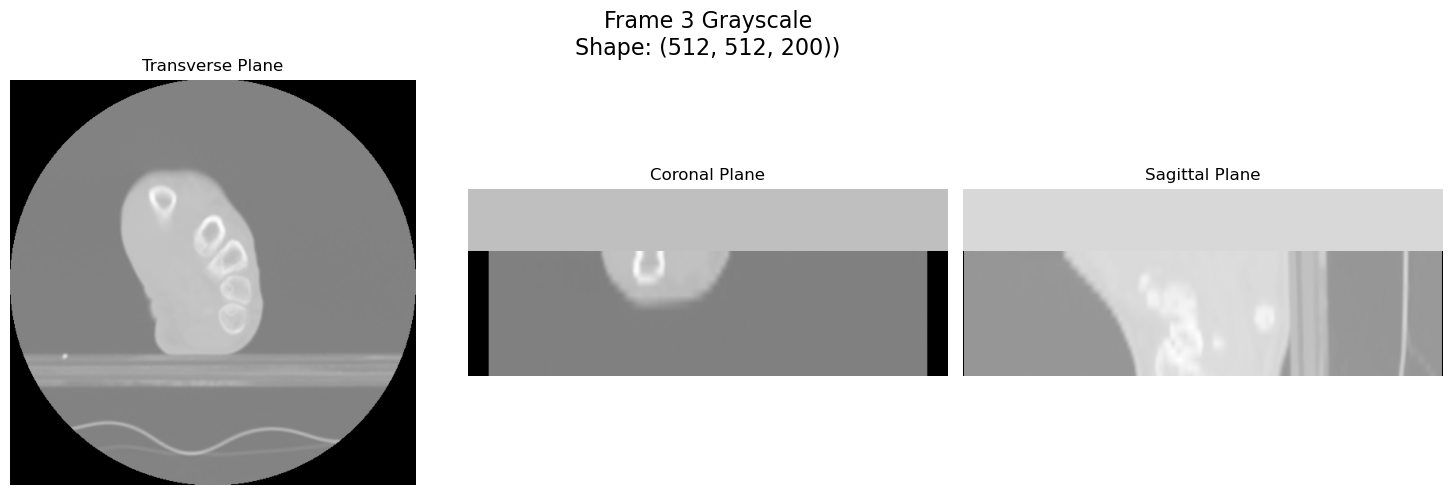

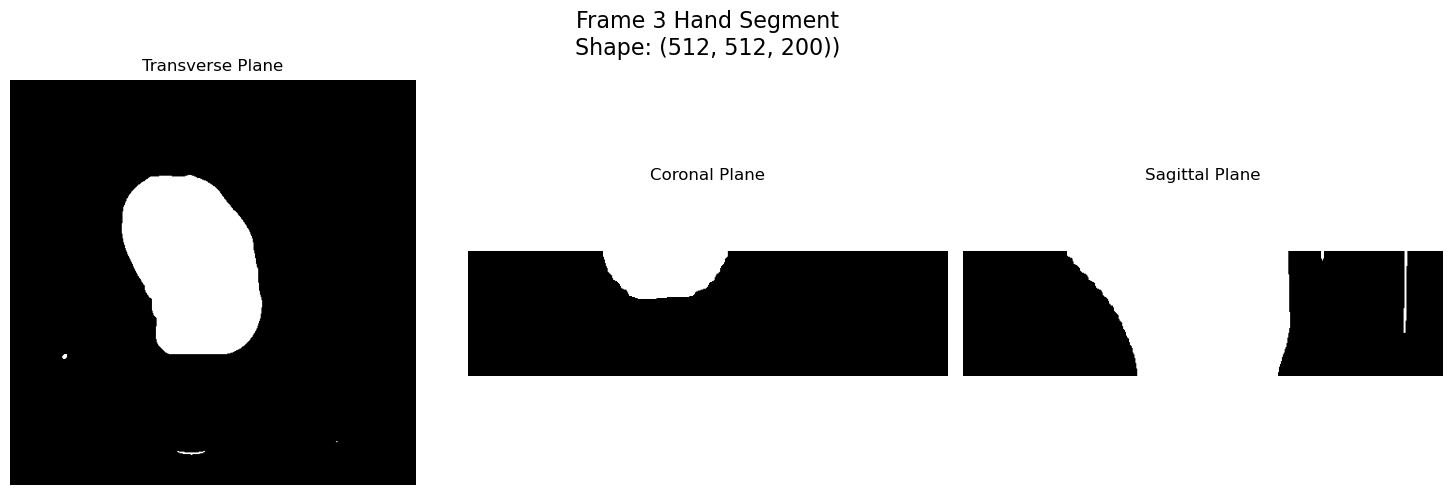

In [9]:
prev_greyscale_dir = os.path.join(dynact_dir, "Volume_" + str(1) + "_Resampled.nii")
prev_grayscale = sitk.ReadImage(prev_greyscale_dir, sitk.sitkFloat32)
print_image(prev_grayscale, title='Frame 1 Grayscale')

prev_hand_seg = sitk.BinaryThreshold(prev_grayscale, -200, 10000, 1, 0)
print_image(prev_hand_seg, title='Frame 1 Hand Segment')

current_file_path = os.path.join(dynact_dir, "Volume_" + str(frame) + "_Resampled.nii")
current_image = sitk.ReadImage(current_file_path, sitk.sitkFloat32)
print_image(current_image, title=f"Frame {frame} Grayscale")

current_hand_seg = sitk.BinaryThreshold(current_image, -200, 10000, 1, 0)
print_image(current_hand_seg, title=f"Frame {frame} Hand Segment")

#### Initializing Registration by Matching Geometric Centres of Hand Segments

In [10]:
tmat_hand_init = sitk.CenteredTransformInitializer(
            current_hand_seg,
            prev_hand_seg,
            sitk.Euler3DTransform(),
            sitk.CenteredTransformInitializerFilter.MOMENTS,
        )
tmat_hand_init

<SimpleITK.SimpleITK.Transform; proxy of <Swig Object of type 'itk::simple::Transform *' at 0x7ff49827f750> >

#### Dilating the MC1 Mask to Encompass a Larger Area Around Bone

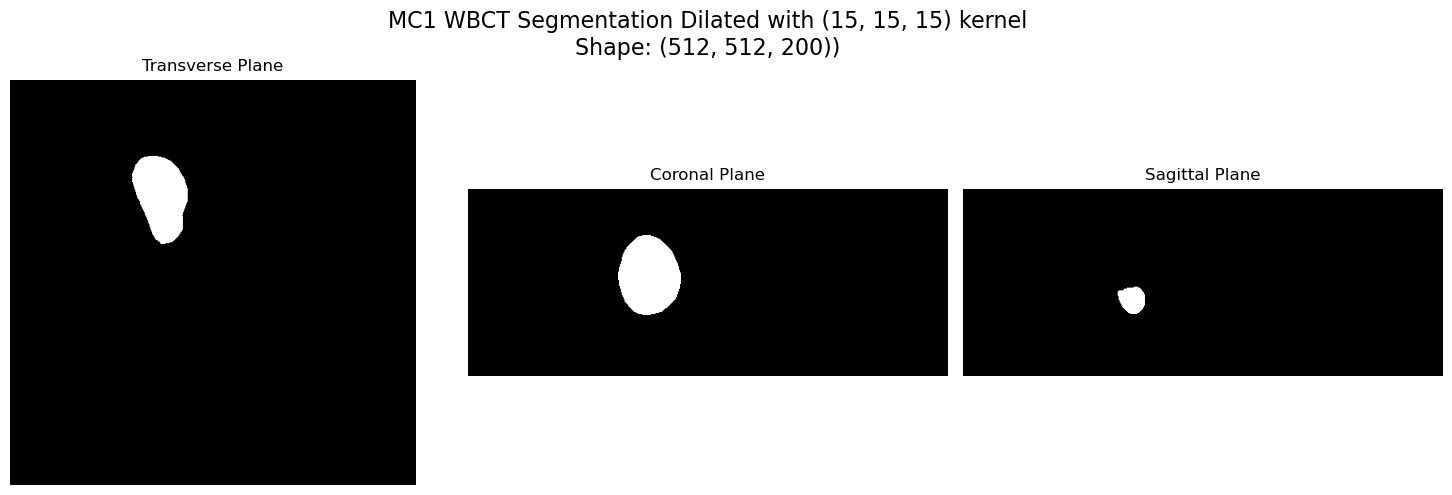

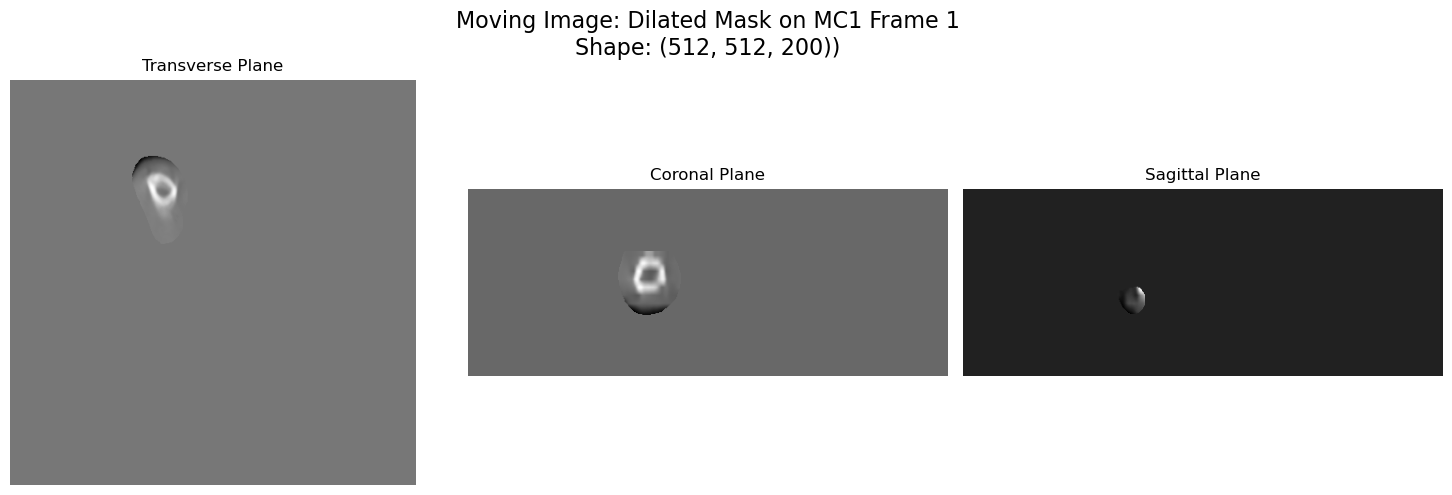

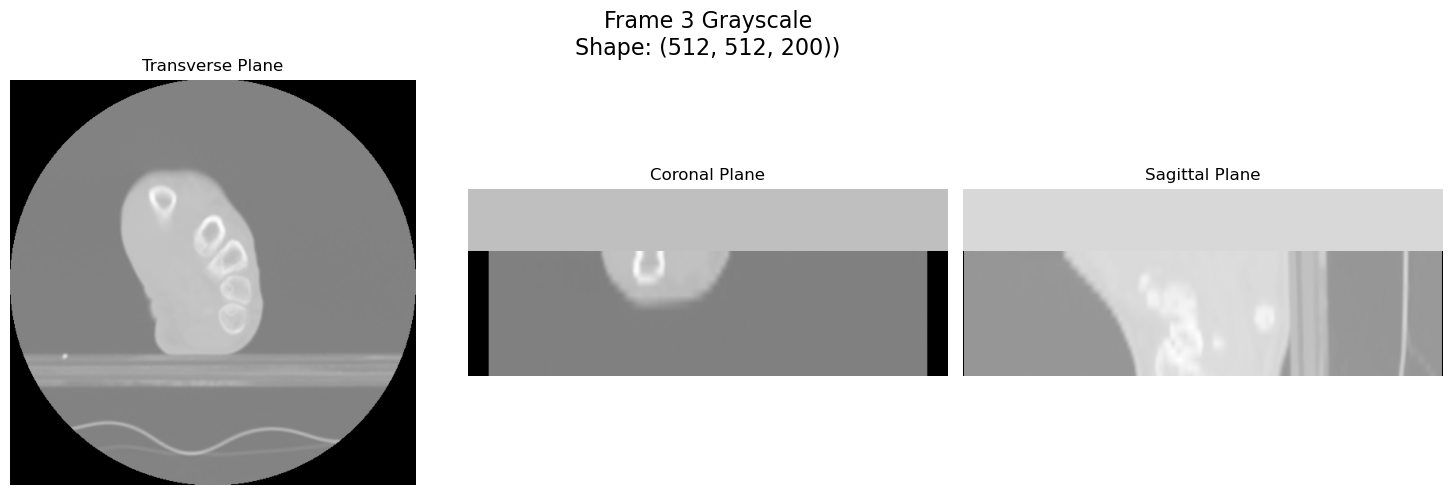

In [11]:
prev_mc1_mask = mc1_seg_resampled
prev_mc1_mask_dilate = sitk.Resample(sitk.BinaryDilate(prev_mc1_mask, dilation_kernel), # larger numbers = bigger mask
                                 prev_grayscale, 
                                 interpolator=sitk.sitkNearestNeighbor)
print_image(prev_mc1_mask_dilate, title=f'MC1 WBCT Segmentation Dilated with {dilation_kernel} kernel')

prev_masked_mc1 = sitk.Mask(prev_grayscale, prev_mc1_mask_dilate)
print_image(prev_masked_mc1, title="Moving Image: Dilated Mask on MC1 Frame 1")

print_image(current_image, title=f"Frame {frame} Grayscale")

#### New Initialization Matching Geometric Centers of Fixed and Moving Images + Running Registration

In [12]:
reg = sitk.ImageRegistrationMethod()

reg.SetMetricAsMeanSquares()
reg.SetMetricSamplingStrategy(reg.RANDOM)

reg.SetMetricSamplingPercentage(0.5)
# reg.SetMetricSamplingPercentagePerLevel([0.1, 0.01, 0.01], 0)

reg.SetOptimizerAsRegularStepGradientDescent(
                learningRate=0.5,
                minStep=1e-8,
                numberOfIterations=1000,
                gradientMagnitudeTolerance=1e-8
            )

reg.SetInterpolator(sitk.sitkLinear)

reg.SetOptimizerScalesFromPhysicalShift()

# reg.SetShrinkFactorsPerLevel(shrinkFactors=[4, 2, 1])
# reg.SetSmoothingSigmasPerLevel(smoothingSigmas=[2, 1, 0])
# reg.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

reg.SetInitialTransform(tmat_hand_init, inPlace=False)

reg.SetMetricMovingMask(prev_masked_mc1)

In [13]:
final_tmat = reg.Execute(current_image, prev_grayscale)

print("Final metric value: {0}".format(reg.GetMetricValue()))
print(
    "Optimizer's stopping condition, {0}".format(
        reg.GetOptimizerStopConditionDescription()
    )
)

Final metric value: 34836.59979971465
Optimizer's stopping condition, RegularStepGradientDescentOptimizerv4: Step too small after 936 iterations. Current step (7.45058e-09) is less than minimum step (1e-08).


#### Showing Transformation on a simple geometric shape

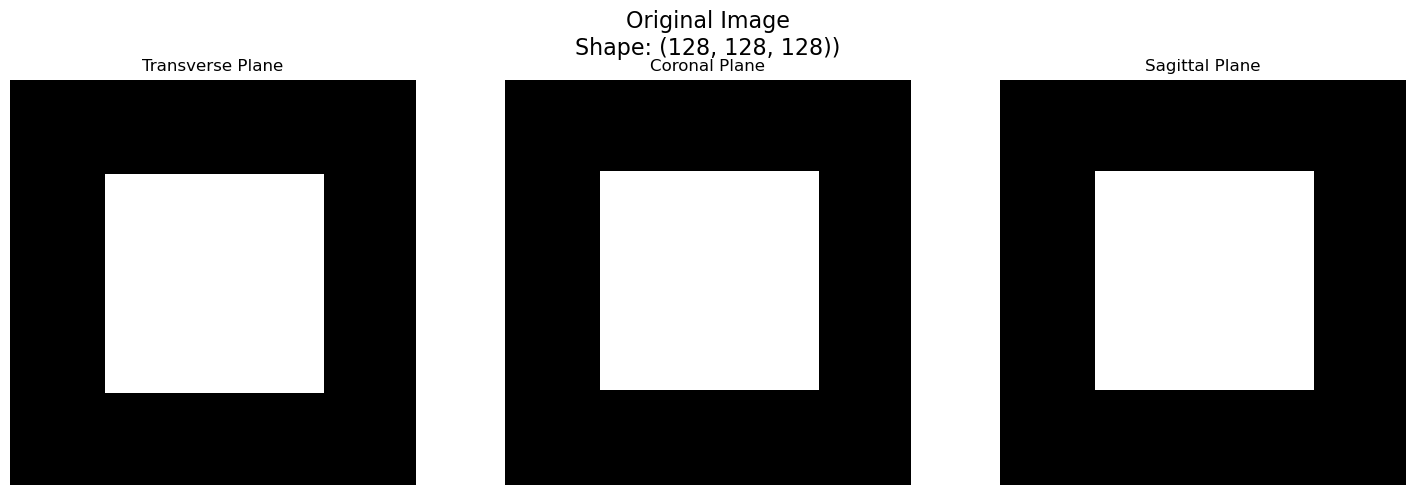

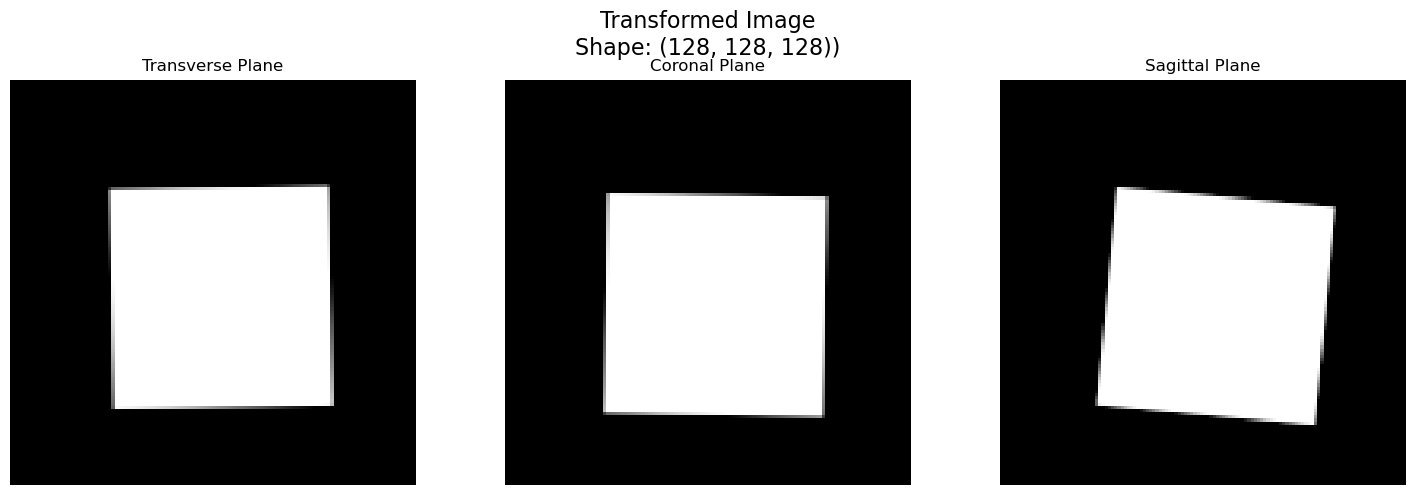

In [14]:
image_3D = sitk.Image(128, 128, 128, sitk.sitkInt16)
array = sitk.GetArrayFromImage(image_3D)
start_point = (30, 30, 30) 
end_point = (128-30, 128-30, 128-30) 
intensity_value = 1000
array[start_point[2]:end_point[2]+1, start_point[1]:end_point[1]+1, start_point[0]:end_point[0]+1] = intensity_value
image_with_rectangle = sitk.GetImageFromArray(array)
print_image(image_with_rectangle, full=False, title="Original Image")

transformed_image = sitk.Resample(image_with_rectangle, transform=final_tmat)
print_image(transformed_image, full=False, title="Transformed Image")

#### Applying Transforms to Previous Mask

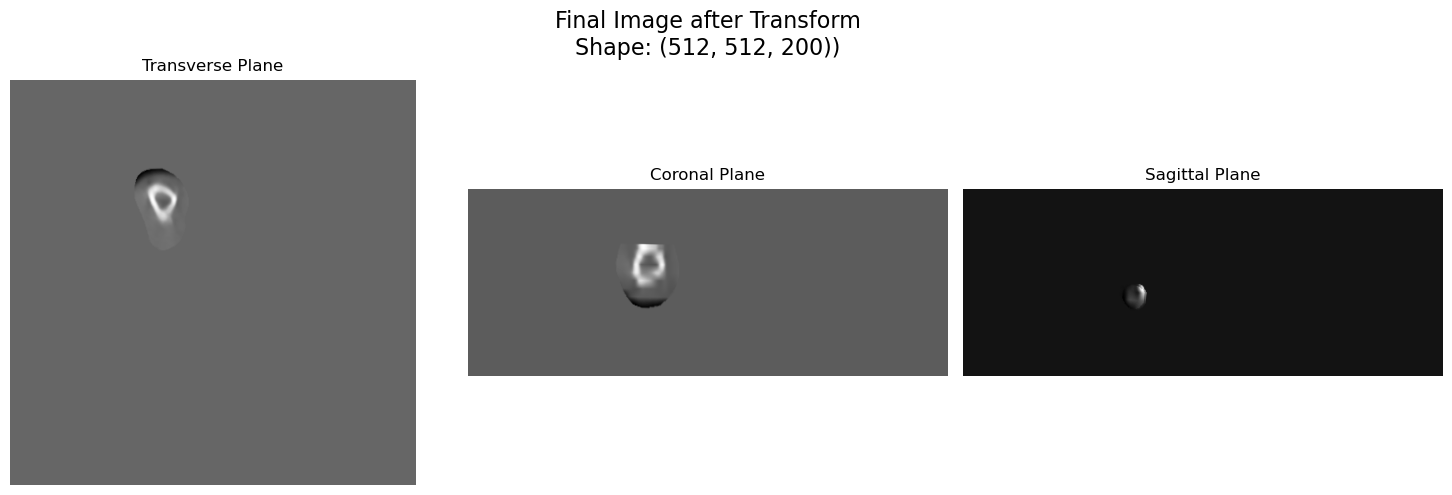

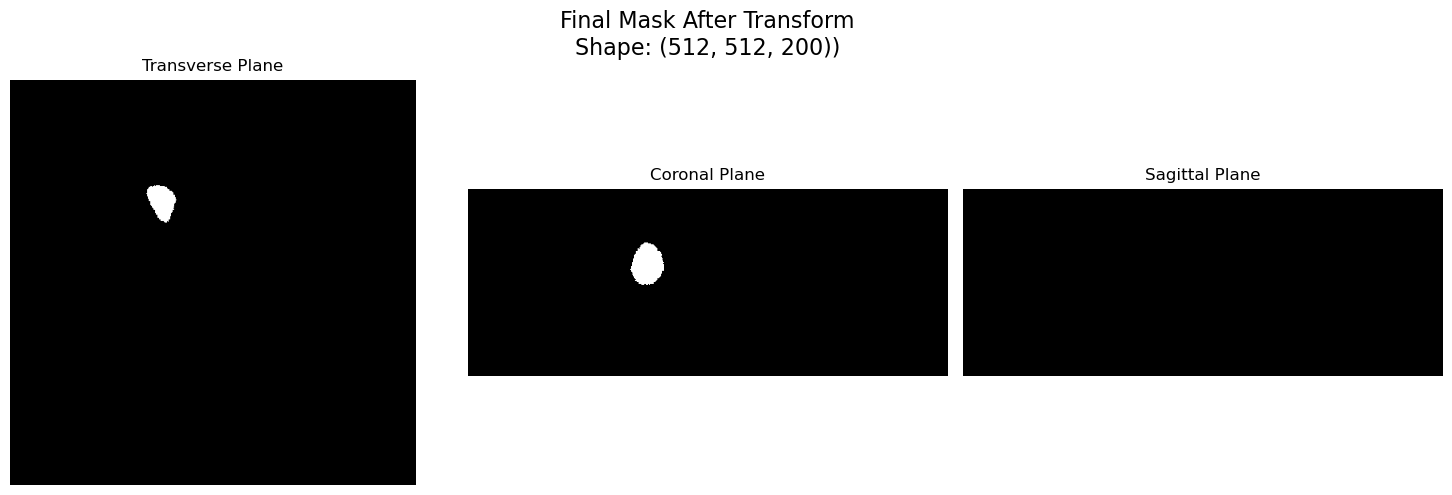

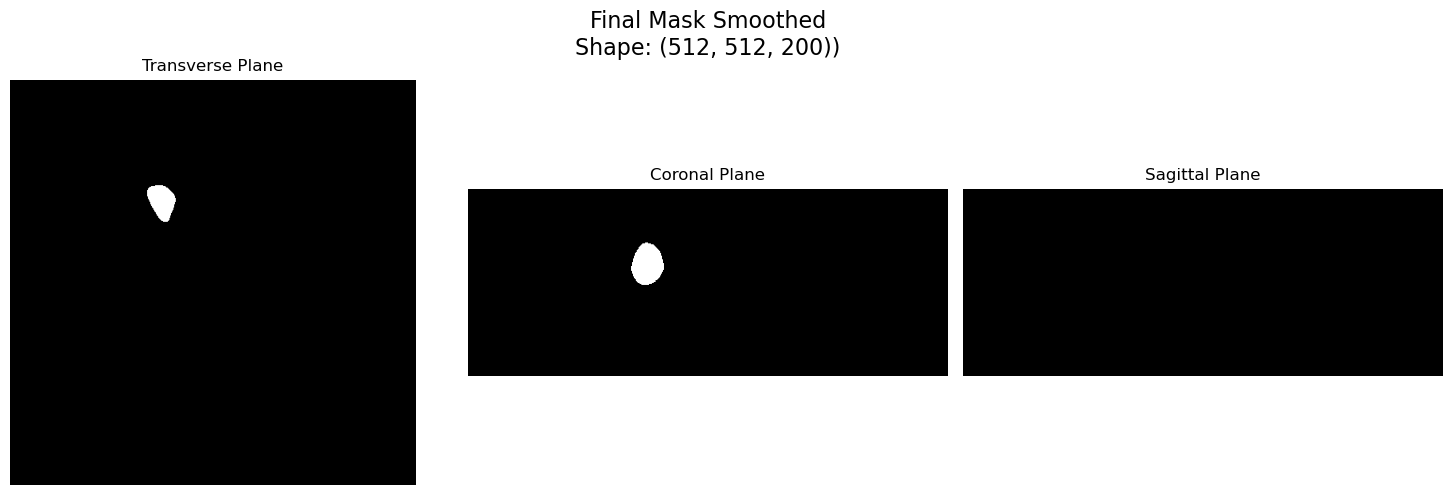

In [15]:
final_image = sitk.Resample(prev_masked_mc1, current_image, transform=final_tmat)
print_image(final_image, title='Final Image after Transform')

final_mask = sitk.Resample(prev_mc1_mask, transform=final_tmat, interpolator=sitk.sitkNearestNeighbor)
print_image(final_mask, title='Final Mask After Transform')

final_mask = sitk.BinaryMedian(final_mask, [2,2,2])
print_image(final_mask, title='Final Mask Smoothed')

#### Applying Mask to Current Image so that we can calculate intensity

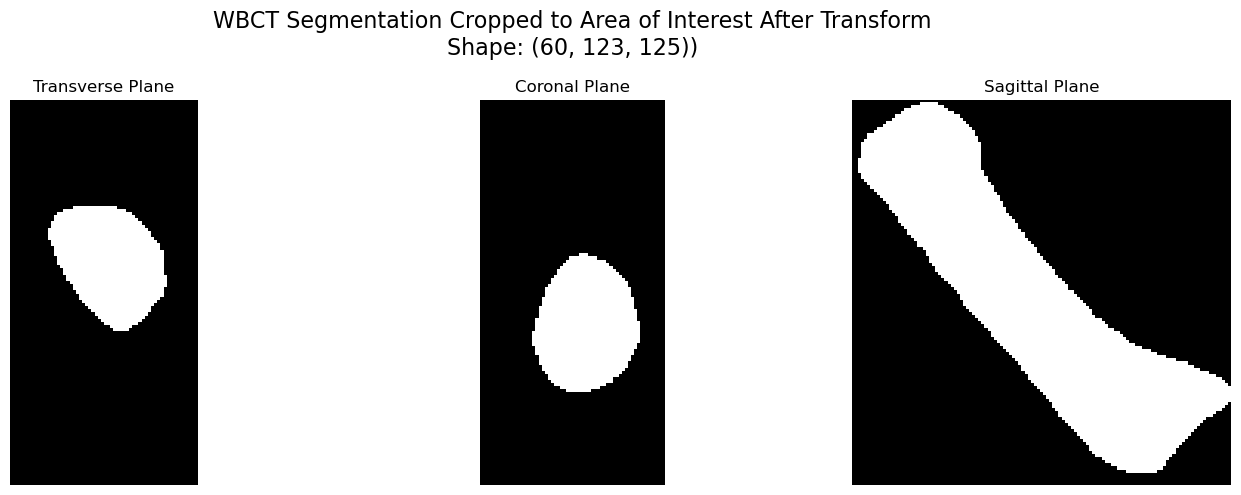

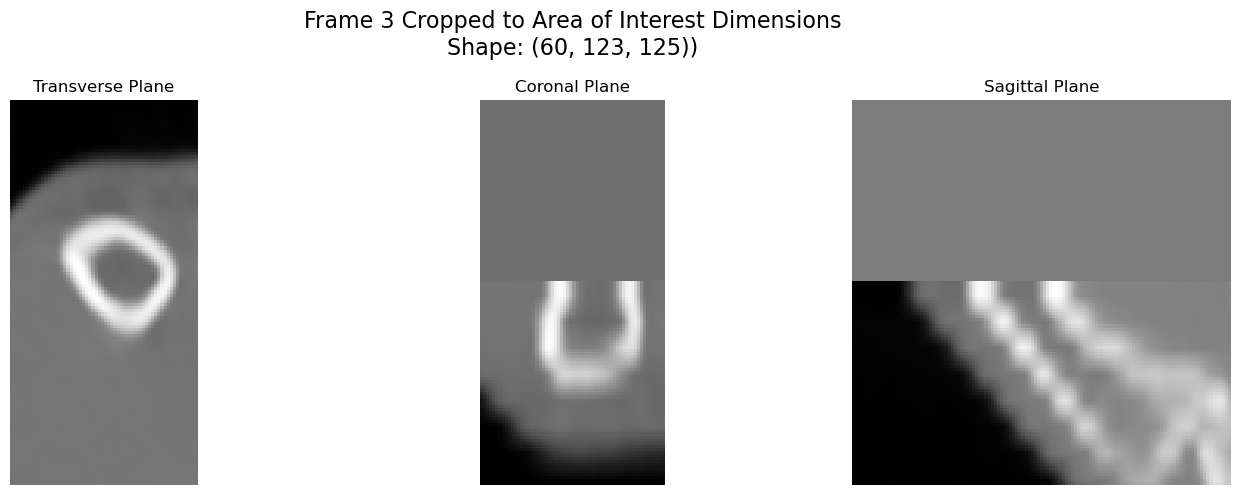

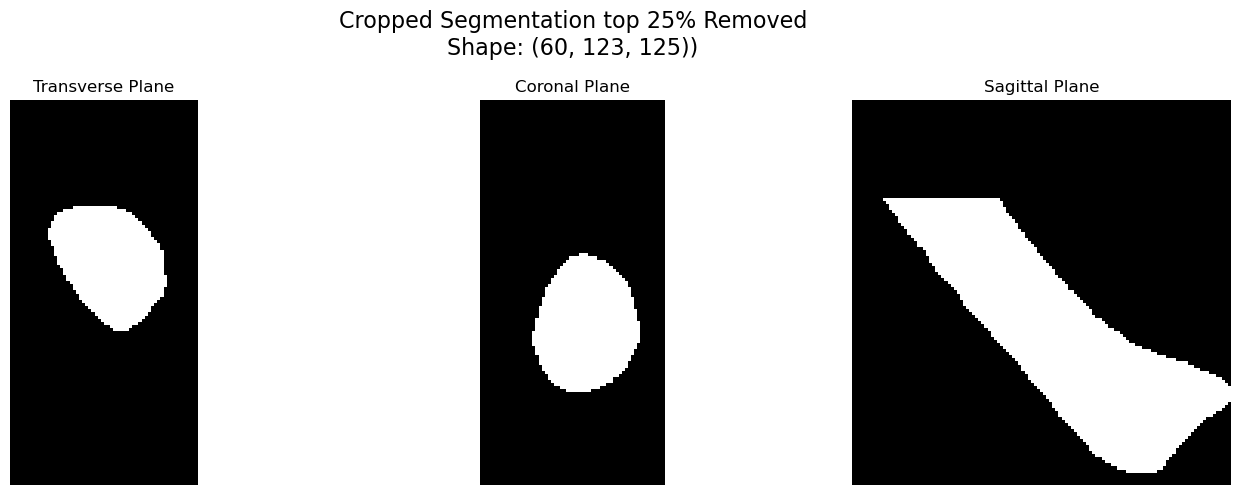

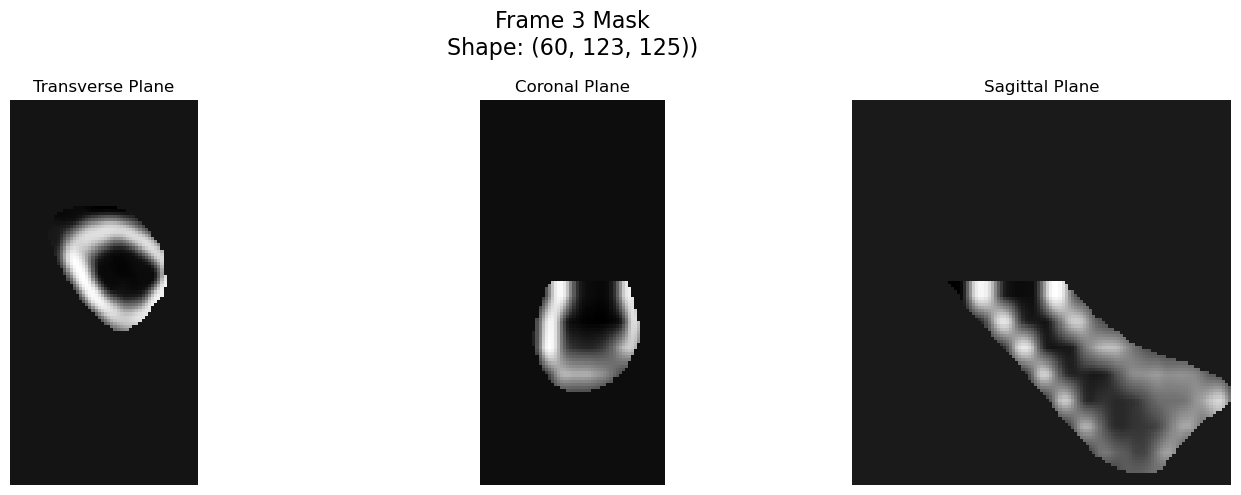

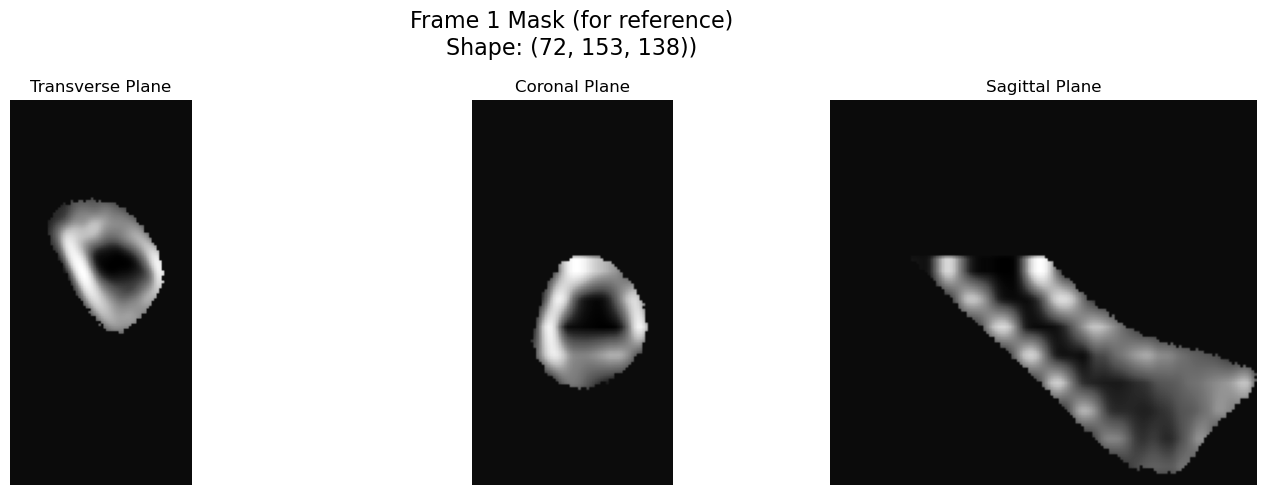

In [16]:
# cropping transformed segmentation to area of interest
mask = bounding_box(final_mask, 1, 1)
print_image(mask, full=False, title="WBCT Segmentation Cropped to Area of Interest After Transform")

# cropping current grayscale to transformed segmentation dimensions
current_grayscale = sitk.Resample(current_image, mask)
print_image(current_grayscale, full=False, title=f"Frame {frame} Cropped to Area of Interest Dimensions")

# removing top 25% of segmentation            
mask = sitk.Resample(mask[:,:,0:int(mask.GetSize()[2]*0.75)], mask)
print_image(mask, full=False, title='Cropped Segmentation top 25% Removed')

# applying mask on current dynamic ct with transformed segmentation
current_grayscale = sitk.Mask(current_grayscale, mask)
print_image(current_grayscale, full=False, title=f"Frame {frame} Mask")

print_image(frame_1_dynact, full=False, title="Frame 1 Mask (for reference)")

#### Comparing Intensities

In [17]:
new_intensity_mc1 = ((sitk.GetArrayFromImage(current_grayscale)[(sitk.GetArrayFromImage(mask) > 0) & (np.absolute(sitk.GetArrayFromImage(current_grayscale)) > 0)])).mean()
print("REF MC1 INTENSITY:", start_intensity_mc1)
print("CURRENT MC1 INTENSITY:", new_intensity_mc1)

REF MC1 INTENSITY: 493.45755
CURRENT MC1 INTENSITY: 471.7071
